In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import torch
import json
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
from matplotlib.ticker import MultipleLocator


settings_file_path = f"../../../settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
current_model = settings['current_model']

data_path = f"ERA5_analysis_results/final_analysis_ERA5_inherent_detrended_test_set/model_{current_model}/trained_for_80_epochs_/period_1850_2100/data/"


In [2]:
cq_fact_memb0 = np.load(f"{data_path}/cq_spatial_test_member0_factual_01-99.npy")
cq_cf_memb0 = np.load(f"{data_path}/cq_spatial_test_member0_counterfactual_01-99.npy")

# load mae
mae_fact = torch.load(f"{data_path}/all_mae_fact.pt")
mae_cf = torch.load(f"{data_path}/all_mae_cf.pt")

font size: 4.571428571428572
cq_fact: (648, 99)
fact_quantiles: (99, 99)
fact_quantiles: (99,)
mae_fact: 0.08638059795954535
mae_cf: 0.07952165767955242


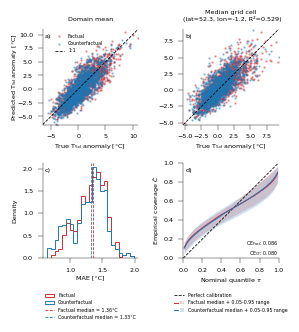

In [3]:
# final version
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
REFERENCE_FONT_SIZE = 8        # font size tuned for REFERENCE_WIDTH_MM
REFERENCE_LEGEND_FONT_SIZE = 6  # legend font size tuned for REFERENCE_WIDTH_MM
REFERENCE_MARKER_SIZE = 1
REFERENCE_LINEWIDTH_THIN = 1.0
REFERENCE_LINEWIDTH_THICK = 1.2

FIG_WIDTH_MM = 153 * 0.4       # matplotlib canvas size at save time
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 1.0

FINAL_WIDTH_MM = 153 * 0.7     # width the figure will actually be displayed/printed at

GEN_TO_FINAL = FIG_WIDTH_MM / FINAL_WIDTH_MM

FONT_SIZE = REFERENCE_FONT_SIZE * GEN_TO_FINAL      # no DISPLAY_SCALE**0.5
LEGEND_FONT_SIZE = REFERENCE_LEGEND_FONT_SIZE * GEN_TO_FINAL
MARKER_SIZE = REFERENCE_MARKER_SIZE * GEN_TO_FINAL
LINE_WIDTH = REFERENCE_LINEWIDTH_THIN * GEN_TO_FINAL
LINE_WIDTH_THICK = REFERENCE_LINEWIDTH_THICK * GEN_TO_FINAL
labelpad = -1

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.5 * GEN_TO_FINAL,
    "xtick.major.width": 0.5 * GEN_TO_FINAL,
    "ytick.major.width": 0.5 * GEN_TO_FINAL,
})

print("font size:", FONT_SIZE)

# ---------------------------------------------------------------------
# Load data for new top-row panels
# ---------------------------------------------------------------------

# --- FR domain-mean data ---
domain = "FR"  # or "GER", "SP" — whichever file you're loading
ds_fr = xr.open_dataset(f"{data_path}domain_mean_{domain}.nc")
true_fact_mean_fr = ds_fr["true_fact_mean"].values
dae_fact_mean_fr = ds_fr["dae_fact_mean_ensmedian"].values
true_cf_mean_fr = ds_fr["true_cf_mean"].values
dae_cf_mean_fr = ds_fr["dae_cf_mean_ensmedian"].values

# --- Median grid-cell data ---
ds_cells = xr.open_dataset(f"{data_path}percentile_selected_gridcells_fact_cf.nc")
t_p50 = ds_cells["true_fact_p50"].values
p_p50 = ds_cells["pred_fact_p50"].values
t_p50_cf = ds_cells["true_cf_p50"].values
p_p50_cf = ds_cells["pred_cf_p50"].values
r2_p50_val = float(ds_cells.r2_p50)
lat_p50, lon_p50 = float(ds_cells.lat_p50), float(ds_cells.lon_p50)

# ---------------------------------------------------------------------
# Convert MAE tensors to NumPy
# ---------------------------------------------------------------------

mae_fact_np = mae_fact.detach().cpu().numpy().ravel()
mae_cf_np = mae_cf.detach().cpu().numpy().ravel()

all_mae = np.concatenate([mae_fact_np, mae_cf_np])
all_mae = all_mae[~np.isnan(all_mae)]

# ---------------------------------------------------------------------
# Prepare calibration data
# ---------------------------------------------------------------------

cq_fact = cq_fact_memb0.copy()

cq_cf = cq_cf_memb0.copy()

quantiles = np.linspace(0.01, 0.99, 99)
print("cq_fact:", cq_fact.shape)
fact_quantiles = np.quantile(cq_fact, quantiles, axis=0)
cf_quantiles = np.quantile(cq_cf, quantiles, axis=0)

# ---------------------------------------------------------------------
# Compute CE of median claibration
# ---------------------------------------------------------------------
print("fact_quantiles:", fact_quantiles.shape)
print("fact_quantiles:", fact_quantiles[49, :].shape)
ce_fact = np.mean(np.abs(fact_quantiles[49, :] - quantiles))
ce_cf = np.mean(np.abs(cf_quantiles[49, :] - quantiles))
print("mae_fact:", ce_fact)
print("mae_cf:", ce_cf)



# ---------------------------------------------------------------------
# Compute MAE medians
# ---------------------------------------------------------------------

median_fact = np.median(mae_fact_np)
median_cf = np.nanmedian(mae_cf_np)

# ---------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    #constrained_layout=True
)

# ---------------------------------------------------------------------
# Panel A (top-left): FR domain-mean true vs. predicted scatter
# ---------------------------------------------------------------------
axes[0, 0].scatter(
    true_fact_mean_fr, dae_fact_mean_fr,
    s=MARKER_SIZE, alpha=0.4, color="tab:red", label="Factual",
)
axes[0, 0].scatter(
    true_cf_mean_fr, dae_cf_mean_fr,
    s=MARKER_SIZE, alpha=0.4, color="tab:blue", label="Counterfactual",
)

lims_a = [
    min(true_fact_mean_fr.min(), dae_fact_mean_fr.min(),
        true_cf_mean_fr.min(), dae_cf_mean_fr.min()),
    max(true_fact_mean_fr.max(), dae_fact_mean_fr.max(),
        true_cf_mean_fr.max(), dae_cf_mean_fr.max()),
]
axes[0, 0].plot(
    lims_a, lims_a,
    linestyle="--", color="black", linewidth=LINE_WIDTH,
    label="1:1",
)
axes[0, 0].set_xlim(lims_a)
axes[0, 0].set_ylim(lims_a)
axes[0, 0].set_xlabel("True " + r"$\mathrm{T_{5d}}$ anomaly [°C]", labelpad=2)
#axes[0, 0].set_ylabel("Predicted domain mean " + r"$\mathrm{T}_{5d}$ [$^\circ$C]", labelpad=labelpad +2)
axes[0, 0].set_ylabel("Predicted" + r" $\mathrm{T_{5d}}$ anomaly [°C]", labelpad=labelpad)
axes[0, 0].set_aspect("equal")
axes[0, 0].set_title("Domain mean")

axes[0, 0].legend(
    #frameon=True,
    #loc="lower right",
    #bbox_to_anchor=(1.2, 0.0),
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.08, 1),
    ncol=1,
    fontsize=LEGEND_FONT_SIZE, #max(FONT_SIZE - 2, 4),
)
axes[0, 0].xaxis.set_major_locator(MultipleLocator(5))

# ---------------------------------------------------------------------
# Panel B (top-right): median grid-cell true vs. predicted scatter
# ---------------------------------------------------------------------

axes[0, 1].scatter(
    t_p50, p_p50,
    s=MARKER_SIZE, alpha=0.4, color="tab:red", label="Factual",
)
axes[0, 1].scatter(
    t_p50_cf, p_p50_cf,
    s=MARKER_SIZE, alpha=0.4, color="tab:blue", label="Counterfactual",
)

lims_b = [
    min(t_p50.min(), p_p50.min(), t_p50_cf.min(), p_p50_cf.min()),
    max(t_p50.max(), p_p50.max(), t_p50_cf.max(), p_p50_cf.max()),
]
axes[0, 1].plot(lims_b, lims_b, linestyle="--", color="black", linewidth=LINE_WIDTH)
axes[0, 1].set_xlim(lims_b)
axes[0, 1].set_ylim(lims_b)
axes[0, 1].set_xlabel("True " + r"$\mathrm{T_{5d}}$ anomaly [°C]", labelpad=2)
#axes[0, 1].set_ylabel("Predicted " + r"$\mathrm{T}_{5d}$ anomaly [$^\circ$C]", labelpad=labelpad)
axes[0, 1].set_title(
    f"Median grid cell\n (lat={lat_p50:.1f}, lon={lon_p50:.1f}, R²={r2_p50_val:.3f})",
    fontsize=FONT_SIZE, #max(FONT_SIZE - 1, 4),
)
axes[0, 1].set_aspect("equal")
axes[0, 1].set_xlim(lims_b)
axes[0, 1].set_ylim(lims_b)
axes[0, 1].xaxis.set_major_locator(MultipleLocator(2.5))

# ---------------------------------------------------------------------
# Panel C (bottom-left): MAE histograms
# ---------------------------------------------------------------------

bins = np.histogram_bin_edges(all_mae, bins="auto")

axes[1, 0].hist(
    mae_fact_np,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=LINE_WIDTH_THICK,
    label="Factual",
    color="tab:red"
)

axes[1, 0].hist(
    mae_cf_np,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=LINE_WIDTH_THICK,
    label="Counterfactual",
    color="tab:blue"
)

axes[1, 0].axvline(
    median_fact,
    color="tab:red",
    linestyle="--",
    linewidth=LINE_WIDTH,
    label=f"Factual median = {median_fact:.2f}°C",
    zorder=10
)

axes[1, 0].axvline(
    median_cf,
    color="tab:blue",
    linestyle="--",
    linewidth=LINE_WIDTH,
    label=f"Counterfactual median = {median_cf:.2f}°C",
    zorder=10
)

axes[1, 0].set_xlabel("MAE [°C]", labelpad=2)
axes[1, 0].set_ylabel("Density", labelpad=labelpad+5)

axes[1, 0].legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.32),
    ncol=1,
    fontsize=LEGEND_FONT_SIZE, #max(FONT_SIZE - 2, 4)
)

# ---------------------------------------------------------------------
# Panel D (bottom-right): spatial calibration
# ---------------------------------------------------------------------

axes[1, 1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=LINE_WIDTH,
    label="Perfect calibration",
)

axes[1, 1].plot(
    quantiles,
    fact_quantiles[49, :],
    color="tab:red",
    linewidth=LINE_WIDTH_THICK,
    label="Factual median",
)

axes[1, 1].fill_between(
    quantiles,
    fact_quantiles[4, :],
    fact_quantiles[-5, :],
    color="tab:red",
    alpha=0.2,
    linewidth=0,
    label="Factual 0.05--0.95 range",
)

axes[1, 1].plot(
    quantiles,
    cf_quantiles[49, :],
    color="tab:blue",
    linewidth=LINE_WIDTH_THICK,
    label="Counterfactual median",
)

axes[1, 1].fill_between(
    quantiles,
    cf_quantiles[4, :],
    cf_quantiles[-5, :],
    color="tab:blue",
    alpha=0.2,
    linewidth=0,
    label="Counterfactual 0.05--0.95 range",
)

axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_xlabel("Nominal quantile " + r"$\tau$", labelpad=2)
axes[1, 1].set_ylabel("Empirical coverage " + r"$\hat{C}$", labelpad=labelpad+2)

# ---------------------------------------------------------------------
# print CE
# ---------------------------------------------------------------------

axes[1, 1].text(0.99, 0.1,                               # x=0.95, y=0.95 in axes coordinates (0-1)
        r"$\mathrm{CE_{CF}}$"+f": {ce_cf:.3f}",
        #r" $\mathrm{\ CE}$:" + f" {mae_qr:.3f}",   # text to display
        transform=axes[1, 1].transAxes,                  # use axes coordinates
        ha='right',                                  # horizontal alignment
        va='top',                                    # vertical alignment
        fontsize=LEGEND_FONT_SIZE,
        color='black'
    )

axes[1, 1].text(0.99, 0.2,                                # x=0.95, y=0.95 in axes coordinates (0-1)
        r"$\mathrm{CE_{Fact}}$"+f": {ce_fact:.3f}",
        #r"$\mathrm{DAE\ CE}$:" + f" {mae_dae:.3f}",   # text to display
        transform=axes[1, 1].transAxes,                       # use axes coordinates
        ha='right',                                   # horizontal alignment
        va='top',                                     # vertical alignment
        fontsize=LEGEND_FONT_SIZE,
        color='black'
    )

# ---------------------------------------------------------------------
# Shared styling
# ---------------------------------------------------------------------

flat_axes = axes.flatten()

#for label, ax in zip(["a)", "b)", "c)", "d)"], flat_axes):
#    ax.text(
#        0.02,
#        0.95,
#        label,
#        transform=ax.transAxes,
#        va="top",
#        ha="left",
#        fontsize=FONT_SIZE,
#    )
#    ax.spines["top"].set_visible(False)
#    ax.spines["right"].set_visible(False)
#    ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)
#    ax.set_box_aspect(1)  # force square panels, top and bottom row alike

for label, ax in zip(["a)", "b)", "c)", "d)"], flat_axes):
    ax.text(0.02, 0.95, label, transform=ax.transAxes, va="top", ha="left", fontsize=FONT_SIZE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)

# Panels A and B: equal data aspect (so the 1:1 line is a true diagonal)
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 1].set_aspect("equal", adjustable="box")

# Panels C and D: no data-unit relationship — just force a square box
axes[1, 0].set_box_aspect(1)
axes[1, 1].set_box_aspect(1)

# Custom legend for panel D (calibration)
legend_handles = [
    Line2D(
        [0], [0],
        linestyle="--",
        color="black",
        linewidth=LINE_WIDTH,
        label="Perfect calibration",
    ),
    (
        Line2D([0], [0], color="tab:red", linewidth=LINE_WIDTH_THICK),
        Patch(facecolor="tab:red", alpha=0.2, edgecolor="none"),
    ),
    (
        Line2D([0], [0], color="tab:blue", linewidth=LINE_WIDTH_THICK),
        Patch(facecolor="tab:blue", alpha=0.2, edgecolor="none"),
    ),
]

axes[1, 1].legend(
    handles=legend_handles,
    labels=[
        "Perfect calibration",
        "Factual median + 0.05-0.95 range",
        "Counterfactual median + 0.05-0.95 range",
    ],
    handler_map={tuple: HandlerTuple(ndivide=None)},
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.32),
    ncol=1,
    fontsize=LEGEND_FONT_SIZE, #max(FONT_SIZE - 2, 4),
)

fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.05, wspace=0.4, hspace=0.4)

fig.savefig("FigureS8.pdf", bbox_inches="tight")
plt.show()